# 07 · Cell types and proportions

In this notebook you will:

- cluster cells on the **identity** panel to find cell states
- read a cluster's identity off its marker profile, and spot one that is an artefact
- watch a differentiated state emerge over 36–84 hours
- ask which perturbations block or promote it
- and settle, with a number, **what the replicate unit is**

The four theme chapters asked how much of a marker a cell has. This one asks a
different question: **what kind of cell is it, and how many of each kind are there?**

In [1]:
import sys
from pathlib import Path

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from scipy import stats

sys.path.insert(0, str(Path.cwd().parents[1] / "src"))

from mcs2026 import analysis, panels, plotting
from mcs2026.config import H5AD_SLIM

plotting.set_style()
pd.set_option("display.width", 140)

cells = sc.read_h5ad(H5AD_SLIM.with_name("mcs2026_qc.h5ad"))
print(f"{cells.n_obs:,} cells")

39,550 cells


## 1. The identity panel

Seven transcription factors, chosen because they mark the lineages a naive human
embryonic stem cell can become:

| markers | lineage |
|---|---|
| Oct4, Nanog, Sox2 | **pluripotent** — the starting state |
| GATA3 | **trophectoderm** |
| GATA4, GATA6, SOX17 | **hypoblast** (primitive endoderm) |

In [2]:
identity = panels.markers("identity")
columns = [
    cells.var.index[(cells.var.marker == marker)
                    & (cells.var.statistic == "mean_intensity")
                    & (cells.var.family == "Intensity")][0]
    for marker in identity
]
pd.DataFrame({"marker": identity, "column": columns,
              "round": cells.var.loc[columns, "round"].values})

,marker,column,round
0,Oct4,cells_Intensity_mean_intensity_Texas Red_1,1
1,Nanog,cells_Intensity_mean_intensity_FITC_1,1
2,Sox2,cells_Intensity_mean_intensity_Cy5_3,3
3,GATA3,cells_Intensity_mean_intensity_FITC_14,14
4,GATA4,cells_Intensity_mean_intensity_Cy5_2,2
5,GATA6,cells_Intensity_mean_intensity_Texas Red_2,2
6,SOX17,cells_Intensity_mean_intensity_FITC_4,4


## 2. Scale within timepoint

Chapter 02 established that intensities are not comparable across imaging rounds. Here
there is a second reason to be careful: we want clusters that describe **cell state**,
not **timepoint**. If the four timepoints sit at different absolute levels, clustering
will happily hand back four clusters that are really the four timepoints.

So each marker is z-scored *within* each timepoint.

In [3]:
raw = pd.DataFrame(np.log2(np.asarray(cells[:, columns].X) + 1), columns=identity)
timepoint = cells.obs.timepoint_h.astype(int).values

scaled = raw.copy()
for value in [36, 48, 60, 84]:
    mask = timepoint == value
    block = raw.loc[mask]
    scaled.loc[mask] = (block - block.mean()) / block.std()

scaled.describe().loc[["mean", "std"]].round(2)

,Oct4,Nanog,Sox2,GATA3,GATA4,GATA6,SOX17
mean,-0.0,0.0,0.0,-0.0,0.0,-0.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0


## 3. Cluster

A neighbour graph on seven markers, then Leiden. The resolution controls how many
clusters you get, and it is a **choice**, not a result — see the exercises.

In [4]:
subset = ad.AnnData(scaled.values.astype("float32"))
subset.var_names = identity
sc.pp.neighbors(subset, n_neighbors=15, use_rep="X", random_state=0)
sc.tl.leiden(subset, resolution=0.1, flavor="igraph", n_iterations=2, random_state=0)

clusters = subset.obs.leiden.astype(str).values
pd.Series(clusters).value_counts().sort_index().rename("cells")

0    23587
1    13424
2       49
3     2490
Name: cells, dtype: int64

## 4. What is each cluster?

A cluster number means nothing. Read the marker profile and give it a name.

In [5]:
profile = scaled.groupby(clusters).mean()
profile.index.name = "cluster"
profile.round(2)

,Oct4,Nanog,Sox2,GATA3,GATA4,GATA6,SOX17
cluster,,,,,,,
0,0.60,0.55,0.70,-0.11,-0.20,0.21,-0.27
1,-0.96,-0.84,-1.09,0.41,-0.21,-0.43,0.16
2,0.56,0.37,0.92,-4.62,0.05,0.77,0.72
3,-0.53,-0.67,-0.78,-1.09,3.00,0.33,1.68


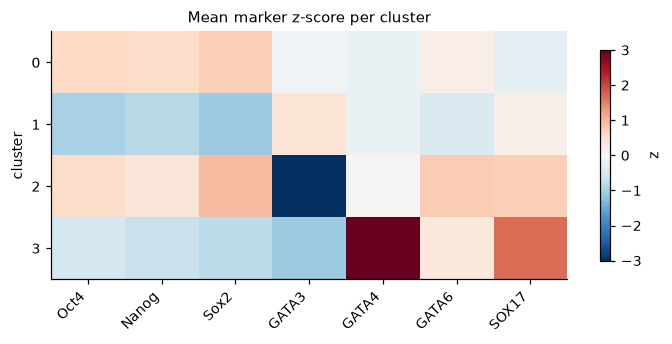

In [6]:
fig, ax = plt.subplots(figsize=(6.5, 3.2))
im = ax.imshow(profile.values, cmap="RdBu_r", vmin=-3, vmax=3, aspect="auto")
ax.set(yticks=range(len(profile)), yticklabels=profile.index, ylabel="cluster")
ax.set_xticks(range(len(identity)))
ax.set_xticklabels(identity, rotation=45, ha="right")
ax.set_title("Mean marker z-score per cluster")
fig.colorbar(im, ax=ax, shrink=0.85, label="z")
fig.tight_layout()

Reading the rows:

- one cluster is **high on Oct4, Nanog and Sox2** — still pluripotent
- one is **high on GATA3** with pluripotency low — trophectoderm-like
- one is **high on GATA4 and SOX17** — hypoblast
- and one is tiny, with a single marker at roughly −4.6

That last one deserves attention.

In [7]:
sizes = pd.Series(clusters).value_counts()
suspicious = profile.abs().max(axis=1).idxmax()
print(f"cluster {suspicious}: {sizes[suspicious]} cells "
      f"({sizes[suspicious] / len(clusters):.3%} of the data)")
profile.loc[[suspicious]].round(2)

cluster 2: 49 cells (0.124% of the data)


,Oct4,Nanog,Sox2,GATA3,GATA4,GATA6,SOX17
cluster,,,,,,,
2,0.56,0.37,0.92,-4.62,0.05,0.77,0.72


:::{warning}
**This is not a cell state.** A few dozen cells, defined by one marker being extremely
*low* rather than any marker being high, is the signature of a technical failure — a
field where that staining round did not work, or a registration slip.

A cluster is only a cell type if you can say what it is *positive* for. Drop it, and
say that you did.
:::

In [8]:
state_names = {}
for cluster in profile.index:
    row = profile.loc[cluster]
    if sizes[cluster] < 0.005 * len(clusters):
        state_names[cluster] = "artefact"
    elif row[["Oct4", "Nanog", "Sox2"]].mean() > 0.3:
        state_names[cluster] = "Pluripotent"
    elif row[["GATA4", "SOX17"]].mean() > 0.5:
        state_names[cluster] = "Hypoblast"
    else:
        state_names[cluster] = "TE-like"

state = pd.Series(clusters).map(state_names).values
keep = state != "artefact"
print(f"dropped {(~keep).sum()} artefact cells")
pd.Series(state[keep]).value_counts().rename("cells")

dropped 49 artefact cells


Pluripotent    23587
TE-like        13424
Hypoblast       2490
Name: cells, dtype: int64

## 5. The hypoblast emerges

In [9]:
by_time = pd.crosstab(timepoint[keep], state[keep], normalize="index")
by_time.index.name = "hours"
(100 * by_time).round(1)

col_0,Hypoblast,Pluripotent,TE-like
hours,,,
36,1.2,68.3,30.5
48,1.6,59.7,38.7
60,6.4,54.6,39.0
84,15.6,56.6,27.8


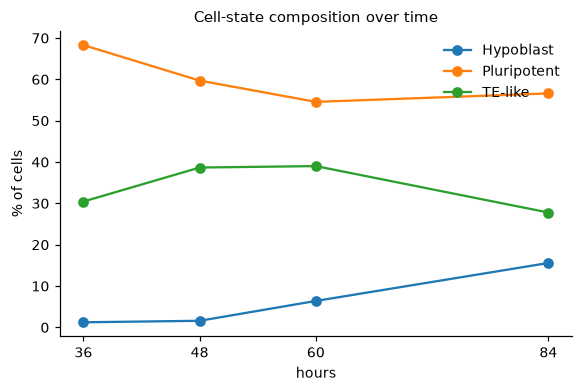

In [10]:
fig, ax = plt.subplots(figsize=(6, 3.6))
for column in by_time.columns:
    ax.plot(by_time.index, 100 * by_time[column], marker="o", label=column)
ax.set(xlabel="hours", ylabel="% of cells", title="Cell-state composition over time")
ax.set_xticks(by_time.index)
ax.legend()

The hypoblast fraction climbs steadily while the culture ages. That is the experiment
working: naive cells left in these conditions specify primitive endoderm, and by 84
hours a substantial minority have done so.

Everything that follows asks **which perturbations change that**.

## 6. Proportions per condition — at the well level

Here is the step that matters. We do **not** pool all cells of a condition together.
We compute the composition **of each well**, because the well is what was
independently treated.

In [11]:
frame = pd.DataFrame({
    "well": cells.obs.well.astype(str).values,
    "condition": cells.obs.condition.astype(str).values,
    "timepoint": timepoint,
    "state": state,
})[keep]

proportions = (
    frame.groupby(["condition", "timepoint", "well"])["state"]
    .value_counts(normalize=True)
    .unstack(fill_value=0)
    .reset_index()
)
print(f"{len(proportions)} wells")
proportions.head()

224 wells


state,condition,timepoint,well,Hypoblast,Pluripotent,TE-like
0,Cycloheximide,36,E02,0.027778,0.711111,0.261111
1,Cycloheximide,36,H04,0.000000,0.698113,0.301887
2,Cycloheximide,36,J05,0.017544,0.730994,0.251462
3,Cycloheximide,48,E08,0.005780,0.618497,0.375723
4,Cycloheximide,48,H10,0.000000,0.606557,0.393443


In [12]:
ranking = proportions.groupby("condition")["Hypoblast"].agg(["mean", "count"])
ranking["mean"] = (100 * ranking["mean"]).round(2)
ranking = ranking.sort_values("mean").rename(columns={"mean": "hypoblast %", "count": "wells"})
ranking

,hypoblast %,wells
condition,,
MK-2206,1.31,12
Phorbol 12-myristate 13-acetate (PMA),1.59,12
Cycloheximide,2.06,12
Sapanisertib/INK128,2.74,12
Dorsomorphin,3.69,12
Pd17,3.71,12
PF-4708671,3.77,12
IGF,6.21,12
Geldanamycin,6.56,12


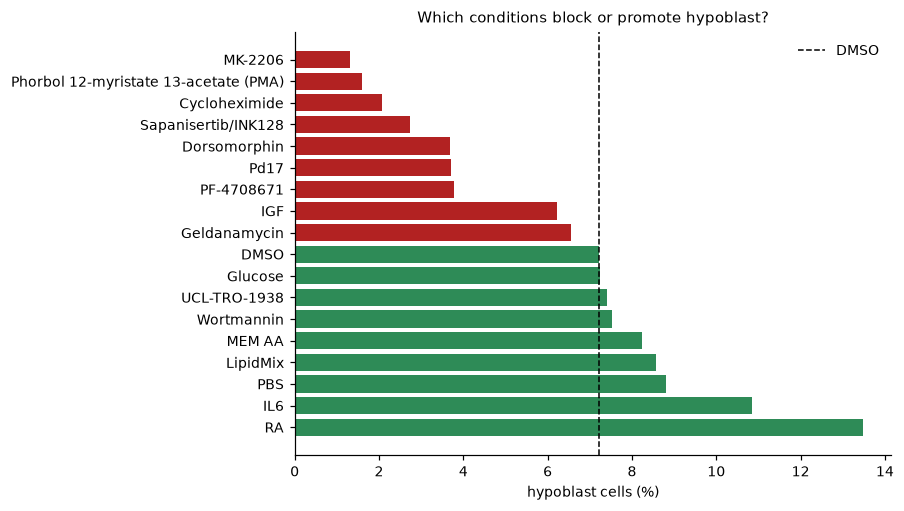

In [13]:
fig, ax = plt.subplots(figsize=(7, 5))
control = ranking.loc["DMSO", "hypoblast %"]
colors = ["firebrick" if v < control else "seagreen" for v in ranking["hypoblast %"]]
ax.barh(range(len(ranking)), ranking["hypoblast %"], color=colors)
ax.axvline(control, color="black", linestyle="--", linewidth=1, label="DMSO")
ax.set(yticks=range(len(ranking)), yticklabels=ranking.index,
       xlabel="hypoblast cells (%)", title="Which conditions block or promote hypoblast?")
ax.invert_yaxis(); ax.legend()

A clear, ordered result:

- **MK-2206 (AKT inhibitor) has the lowest hypoblast fraction of all** — well below
  DMSO. INK128 (mTOR) and PF-4708671 (S6K) sit with it.
- **Retinoic acid has the highest** — well above DMSO.

So the PI3K–AKT–mTOR axis that chapters 03 and 05 found to be pharmacologically
engaged is the same axis that decides whether these cells specify hypoblast. The
marker-level result and the composition-level result are the same story told twice.

In [14]:
for condition in ["MK-2206", "Sapanisertib/INK128", "RA"]:
    print(f"\n{condition} vs DMSO — hypoblast %, per timepoint")
    rows = []
    for value in [36, 48, 60, 84]:
        block = proportions[proportions.timepoint == value]
        treated = block.loc[block.condition == condition, "Hypoblast"]
        reference = block.loc[block.condition == "DMSO", "Hypoblast"]
        rows.append({
            "timepoint": value,
            "treated %": round(100 * treated.mean(), 2),
            "DMSO %": round(100 * reference.mean(), 2),
            "n_wells": len(treated),
            "p": round(stats.mannwhitneyu(treated, reference).pvalue, 4),
            "p_floor": round(analysis.minimum_p(len(treated), len(reference)), 4),
        })
    print(pd.DataFrame(rows).to_string(index=False))


MK-2206 vs DMSO — hypoblast %, per timepoint
 timepoint  treated %  DMSO %  n_wells      p  p_floor
        36       0.97    2.20        3 0.1429   0.0357
        48       0.78    1.82        3 0.3929   0.0357
        60       0.76    6.10        3 0.0357   0.0357
        84       2.72   18.74        3 0.0357   0.0357

Sapanisertib/INK128 vs DMSO — hypoblast %, per timepoint
 timepoint  treated %  DMSO %  n_wells      p  p_floor
        36       1.13    2.20        3 0.0714   0.0357
        48       0.73    1.82        3 0.1429   0.0357
        60       3.36    6.10        3 0.2500   0.0357
        84       5.72   18.74        3 0.0357   0.0357

RA vs DMSO — hypoblast %, per timepoint
 timepoint  treated %  DMSO %  n_wells      p  p_floor
        36       0.57    2.20        3 0.0512   0.0357
        48       3.70    1.82        3 0.2500   0.0357
        60      16.46    6.10        3 0.0357   0.0357
        84      33.21   18.74        3 0.0357   0.0357


At 84 hours the effect is large: DMSO reaches about 19% hypoblast, MK-2206 under 3%,
retinoic acid over 30%.

## 7. The replicate unit, settled

Take the single clearest comparison — MK-2206 against DMSO at 84 hours — and test it
two ways.

In [15]:
late = frame[frame.timepoint == 84]
treated_cells = (late[late.condition == "MK-2206"].state == "Hypoblast").astype(int)
control_cells = (late[late.condition == "DMSO"].state == "Hypoblast").astype(int)

table = np.array([
    [treated_cells.sum(), len(treated_cells) - treated_cells.sum()],
    [control_cells.sum(), len(control_cells) - control_cells.sum()],
])
cell_p = stats.chi2_contingency(table)[1]

block = proportions[proportions.timepoint == 84]
treated_wells = block.loc[block.condition == "MK-2206", "Hypoblast"]
control_wells = block.loc[block.condition == "DMSO", "Hypoblast"]
well_p = stats.mannwhitneyu(treated_wells, control_wells).pvalue

print(f"counting CELLS:  {len(treated_cells)} vs {len(control_cells)}   p = {cell_p:.2e}")
print(f"counting WELLS:  {len(treated_wells)} vs {len(control_wells)}     p = {well_p:.4f}")
print(f"\nsmallest p the well-level design can produce: "
      f"{analysis.minimum_p(len(treated_wells), len(control_wells)):.4f}")

counting CELLS:  549 vs 909   p = 1.43e-18
counting WELLS:  3 vs 5     p = 0.0357

smallest p the well-level design can produce: 0.0357


:::{important}
**The same comparison, off by sixteen orders of magnitude.**

The cell-level p-value treats every cell as an independent experiment. They are not:
cells in one well were pipetted together, treated with the same drop of compound,
incubated in the same corner of the same plate and imaged in the same session. If that
well was mis-pipetted, all several hundred of its cells are wrong together.

The experiment has **3 treated wells**. That is the amount of independent evidence
available, and no amount of imaging can increase it. The well-level p of 0.0357 is not
a weaker result — it is the honest one, and it is sitting exactly on the floor set by
having three wells.

Cell-level statistics are not useless: they describe the *distribution within* a
condition, which is the thing imaging is uniquely good at. But they cannot tell you
that a **treatment** did something. Only replicated treatments can do that.
:::

(0.0, 37.804934823091244)

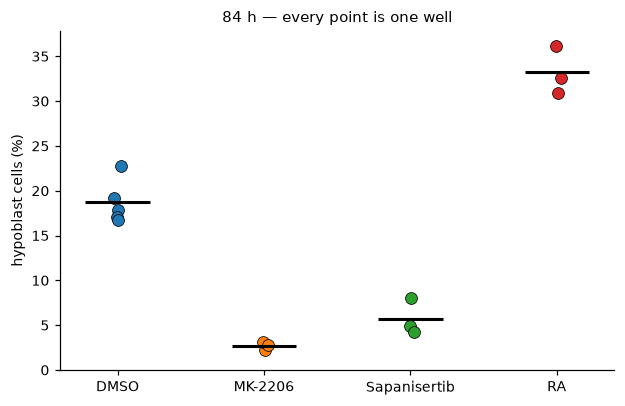

In [16]:
fig, ax = plt.subplots(figsize=(6.5, 4))
conditions = ["DMSO", "MK-2206", "Sapanisertib/INK128", "RA"]
for i, condition in enumerate(conditions):
    values = 100 * block.loc[block.condition == condition, "Hypoblast"]
    ax.scatter(np.full(len(values), i) + np.random.default_rng(0).normal(0, 0.04, len(values)),
               values, s=60, zorder=3, edgecolor="black", linewidth=0.5)
    ax.hlines(values.mean(), i - 0.22, i + 0.22, color="black", linewidth=2, zorder=4)
ax.set(xticks=range(len(conditions)),
       xticklabels=[c.split("/")[0][:12] for c in conditions],
       ylabel="hypoblast cells (%)", title="84 h — every point is one well")
ax.set_ylim(bottom=0)

**Plot the wells.** Three points and a mean say honestly how much evidence there is.
A bar chart with an error bar computed over 40,000 cells would look far more
convincing and would be describing something else entirely.

## 8. Save

In [17]:
cells.obs["cell_state"] = pd.Categorical(
    np.where(keep, state, "artefact"),
    categories=["Pluripotent", "TE-like", "Hypoblast", "artefact"],
)
cells.write_h5ad(H5AD_SLIM.with_name("mcs2026_states.h5ad"), compression="gzip")
proportions.to_parquet(H5AD_SLIM.with_name("mcs2026_proportions.parquet"))
print("saved cell states and well-level proportions")

saved cell states and well-level proportions


---

## Exercises

### 1. Resolution is a choice

Re-run the clustering at resolution 0.05, 0.1 and 0.3. How many clusters do you get,
and do the extra ones at 0.3 have interpretable marker profiles? How would you decide?

:::{admonition} Solution
:class: dropdown

```python
for resolution in [0.05, 0.1, 0.3]:
    sc.tl.leiden(subset, resolution=resolution, key_added=f"r{resolution}",
                 flavor="igraph", n_iterations=2, random_state=0)
    labels = subset.obs[f"r{resolution}"].astype(str).values
    print(f"\nresolution {resolution}: {len(set(labels))} clusters")
    print(scaled.groupby(labels).mean().round(2))
```

At 0.3 you get around ten clusters, and several are hard to name — they differ by
degree rather than by which markers are on. That is the sign you have gone past what
seven markers can support.

The honest test is not a metric but a question: **can you say what each cluster is
positive for?** If not, either lower the resolution or measure more markers. Do not
report clusters you cannot name.
:::

### 2. Does the artefact cluster change any conclusion?

Repeat the MK-2206 comparison keeping the artefact cluster. Does the answer move? Was
dropping it important, or merely tidy?

:::{admonition} Solution
:class: dropdown

It barely moves — the cluster is a few dozen cells out of tens of thousands.

That is worth knowing, and it is not an argument for leaving it in. It happens to be
harmless here because it is tiny and spread across conditions. Had that staining round
failed in one *block* of the plate, the same artefact would sit in one timepoint and
would look exactly like a treatment effect. You cannot tell which case you are in
without looking, which is the reason to look.
:::

### 3. Does composition explain the marker results?

Chapter 03 found that MK-2206 lowers p-S6. This chapter finds it lowers the hypoblast
fraction. Are these the same fact? Compute the mean p-S6 **within each cell state
separately** and see whether MK-2206 still lowers it inside the pluripotent cells.

:::{admonition} Solution
:class: dropdown

```python
ps6 = cells.var.index[(cells.var.marker == "p-S6")
                      & (cells.var.statistic == "mean_intensity")][0]
by_state = pd.DataFrame({
    "value": np.log2(np.asarray(cells[:, ps6].X).ravel() + 1),
    "state": cells.obs.cell_state.astype(str).values,
    "condition": cells.obs.condition.astype(str).values,
    "well": cells.obs.well.astype(str).values,
})
per_well = by_state.groupby(["state", "condition", "well"])["value"].mean().reset_index()
print(per_well[per_well.condition.isin(["DMSO", "MK-2206"])]
      .groupby(["state", "condition"])["value"].mean().unstack().round(2))
```

This is a **composition versus per-cell** question, and it comes up constantly. If a
treatment changes the mixture of cell types, any whole-population average changes too
— without any individual cell having changed.

Here p-S6 stays lower under MK-2206 *within* the pluripotent cells, so the drug is
doing something to cells directly, not only shifting the mixture. Had the effect
vanished inside every state, the correct conclusion would have been the opposite.
:::

---

**Next:** [08 · Integration](08_integration.ipynb) — do the four themes agree?